# Packet-Level Supervised Random Forest Baseline

Train and tune a supervised Random Forest that predicts whether each packet is benign or attack traffic.

## Setup and load the fixed packet splits

Run `scripts/prepare_packet_dataset.py` before this notebook.


In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    make_scorer
)

PROJECT_ROOT = Path("..").resolve()
DATA_FOLDER = "phase3_packet"
DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATA_FOLDER
META_PATH = DATA_DIR / "packet_split_metadata.json"

BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
TARGET_COL = "target"
PACKET_ID_COL = "packet_id"
PACKET_FLOW_KEY_COL = "packet_flow_key"

with open(META_PATH, "r") as f:
    metadata = json.load(f)

train_df = pd.read_csv(DATA_DIR / "packet_train.csv", low_memory=False)
validation_df = pd.read_csv(DATA_DIR / "packet_validation.csv", low_memory=False)
test_df = pd.read_csv(DATA_DIR / "packet_test.csv", low_memory=False)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
metadata


Train shape: (143102, 140)
Validation shape: (31170, 140)
Test shape: (30769, 140)


{'input_path': 'data/samples/packet_sample_seed1.csv',
 'output_dir': 'data/processed/phase3_packet',
 'seed': 1,
 'validation_size': 0.15,
 'test_size': 0.15,
 'group_by_flow': True,
 'group_column': 'packet_flow_key',
 'packet_id_column': 'packet_id',
 'split_rows': {'train': 143102, 'validation': 31170, 'test': 30769},
 'binary_counts': {'train': {'benign': 139614, 'attack': 3488},
  'validation': {'benign': 30418, 'attack': 752},
  'test': {'benign': 29968, 'attack': 801}},
 'attack_type_counts': {'train': {'Benign': 139614,
   'DNS Spoofing': 2147,
   'DDoS-HTTP Flood': 590,
   'Brute Force': 291,
   'DoS-HTTP Flood': 268,
   'XSS': 192},
  'validation': {'Benign': 30418,
   'DNS Spoofing': 499,
   'DDoS-HTTP Flood': 119,
   'Brute Force': 55,
   'XSS': 41,
   'DoS-HTTP Flood': 38},
  'test': {'Benign': 29968,
   'DNS Spoofing': 532,
   'DDoS-HTTP Flood': 124,
   'DoS-HTTP Flood': 58,
   'Brute Force': 58,
   'XSS': 29}},
 'flow_key_overlap': {'train_validation': 0,
  'train_test'

### Verify the class distribution and split integrity

Packets that share the same constructed flow key should remain in one split. This avoids giving the model nearly identical packets from the same flow during both training and testing.


In [2]:
for name, current_df in [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]:
    print(f"{name} binary counts")
    print(current_df[BINARY_COL].value_counts())
    print()

train_keys = set(train_df[PACKET_FLOW_KEY_COL])
validation_keys = set(validation_df[PACKET_FLOW_KEY_COL])
test_keys = set(test_df[PACKET_FLOW_KEY_COL])

print("Packet-flow-key overlap")
print("Train and validation:", len(train_keys & validation_keys))
print("Train and test:", len(train_keys & test_keys))
print("Validation and test:", len(validation_keys & test_keys))


Train binary counts
binary_label
benign    139614
attack      3488
Name: count, dtype: int64

Validation binary counts
binary_label
benign    30418
attack      752
Name: count, dtype: int64

Test binary counts
binary_label
benign    29968
attack      801
Name: count, dtype: int64

Packet-flow-key overlap
Train and validation: 0
Train and test: 0
Validation and test: 0


## Random Forest-specific preprocessing

All feature preparation is defined in this notebook so other models can use their own preprocessing. For this Random Forest, the selected inputs are numeric packet-behaviour features covering ports, protocol flags, packet size, timing, payload statistics, DNS/HTTP/ICMP fields, and rolling traffic statistics.

Raw IP addresses, MAC addresses, device names, source-file names, packet identifiers, and stream identifiers are excluded because they can create identity leakage and do not generalize well. Undefined variance and jitter values are structural for short histories, so they are replaced with zero. Remaining missing values are imputed with the training median, missing-value indicators are added, and constant features are removed. These learned steps remain inside the cross-validation pipeline. Scaling and outlier clipping are not used because tree models are insensitive to feature scale and are generally robust to extreme values.


In [3]:
BASIC_PACKET_FEATURES = [
    "src_port", "dst_port", "inter_arrival_time", "time_since_previously_displayed_frame",
    "port_class_dst", "l4_tcp", "l4_udp", "ttl", "eth_size", "tcp_window_size",
    "payload_entropy", "payload_length", "jitter", "dns_query_type", "dns_len_qry",
    "dns_interval", "dns_len_ans", "http_content_len", "http_response_code",
    "handshake_cipher_suites_length", "handshake_extensions_length",
    "handshake_sig_hash_alg_len", "icmp_type", "icmp_checksum_status",
    "icmp_data_size", "ntp_interval", "l3_ip_dst_count", "min_et", "min_e",
    "var_e", "sum_p", "min_p", "max_p", "med_p", "average_p", "var_p", "iqr_p"
]

ROLLING_PACKET_FEATURES = []
for group in ["stream", "src_ip", "src_ip_mac", "channel"]:
    ROLLING_PACKET_FEATURES += [f"{group}_{window}_count" for window in [1, 5, 30]]
    ROLLING_PACKET_FEATURES += [f"{group}_{window}_{stat}" for window in [5, 30] for stat in ["mean", "var"]]

ROLLING_PACKET_FEATURES += [
    "stream_jitter_5_mean", "stream_jitter_5_var",
    "stream_jitter_30_mean", "stream_jitter_30_var"
]

requested_features = BASIC_PACKET_FEATURES + ROLLING_PACKET_FEATURES
feature_cols = [col for col in requested_features if col in train_df.columns]
missing_features = [col for col in requested_features if col not in train_df.columns]

if not feature_cols:
    raise ValueError("No packet features were found in the split files")
if missing_features:
    print("Unavailable optional features:", missing_features)


def prepare_packet_features(df, columns):
    X = df[columns].copy()

    for col in columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan)
    structural_zero_cols = [col for col in columns if col.endswith("_var") or "jitter" in col]
    X[structural_zero_cols] = X[structural_zero_cols].fillna(0)
    return X


def get_target(df):
    invalid = sorted(set(df[BINARY_COL].astype(str)) - {"benign", "attack"})
    if invalid:
        raise ValueError(f"Unexpected binary labels: {invalid}")
    return df[BINARY_COL].map({"benign": 0, "attack": 1}).astype("int8").to_numpy()


X_train = prepare_packet_features(train_df, feature_cols)
X_validation = prepare_packet_features(validation_df, feature_cols)
X_test = prepare_packet_features(test_df, feature_cols)

y_train = get_target(train_df)
y_validation = get_target(validation_df)
y_test = get_target(test_df)

train_df[TARGET_COL] = y_train
validation_df[TARGET_COL] = y_validation
test_df[TARGET_COL] = y_test

print("Input features:", len(feature_cols))
print("Training missing values before imputation:", int(X_train.isna().sum().sum()))
print("Validation missing values before imputation:", int(X_validation.isna().sum().sum()))
print("Test missing values before imputation:", int(X_test.isna().sum().sum()))


Input features: 69
Training missing values before imputation: 168795
Validation missing values before imputation: 41966
Test missing values before imputation: 35261


/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_77586/1069820771.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[TARGET_COL] = y_train
/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_77586/1069820771.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  validation_df[TARGET_COL] = y_validation
/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_77586/1069820771.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

## Tune Random Forest with 5-fold stratified cross-validation

The search uses only the training split. `StratifiedKFold` preserves the benign-to-attack ratio in every fold. The validation and test splits remain outside the search.

The best configuration is selected using mean cross-validation PR-AUC because attacks are the minority class.


In [4]:
RANDOM_STATE = 1
N_ITER = 12
CLASSIFICATION_THRESHOLD = 0.50

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("remove_constant", VarianceThreshold())
])

random_forest = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest)
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__class_weight": ["balanced", "balanced_subsample"],
    "model__bootstrap": [True, False]
}

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0)
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    return_train_score=False
)

start_search = time.perf_counter()
rf_search.fit(X_train, y_train)
search_time = time.perf_counter() - start_search

rf_pipeline = rf_search.best_estimator_
rf_pipeline.named_steps["model"].set_params(n_jobs=-1)
processed_feature_count = rf_pipeline.named_steps["preprocessor"].named_steps["remove_constant"].get_support().sum()

print(f"Search time: {search_time:.2f} seconds")
print(f"Best mean CV PR-AUC: {rf_search.best_score_:.4f}")
print("Processed features:", processed_feature_count)
print("Best parameters:")
for name, value in rf_search.best_params_.items():
    print(f"  {name}: {value}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 4.4min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 4.5min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 4.6min
[CV] END model__bootstrap=True, model__class_weight=balanced, model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; total time= 2.9min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsam

### Cross-validation results

The table shows the highest-ranked sampled configurations. Rank 1 is the estimator refitted on the complete training split.


In [5]:
cv_results_df = pd.DataFrame(rf_search.cv_results_)

result_columns = [
    "rank_test_pr_auc",
    "mean_test_pr_auc",
    "std_test_pr_auc",
    "mean_test_roc_auc",
    "mean_test_f1",
    "mean_test_precision",
    "mean_test_recall",
    "mean_fit_time",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "param_model__class_weight",
    "param_model__bootstrap"
]

top_cv_results = cv_results_df[result_columns].sort_values("rank_test_pr_auc").head(10)
display(top_cv_results.round(4))


,rank_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,mean_test_f1,mean_test_precision,mean_test_recall,mean_fit_time,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__class_weight,param_model__bootstrap
9,1,0.9933,0.0015,0.9996,0.9612,0.9988,0.9263,556.6148,500,30,5,1,0.3,balanced,False
5,2,0.9917,0.0015,0.9988,0.9618,0.9988,0.9275,342.8142,200,40,2,1,0.5,balanced_subsample,False
3,3,0.9909,0.0018,0.9994,0.9619,0.9960,0.9300,1203.8542,700,None,10,1,0.5,balanced,False
6,4,0.9899,0.0022,0.9994,0.9636,0.9942,0.9349,98.5650,200,None,2,2,0.3,balanced,True
1,5,0.9895,0.0027,0.9994,0.9633,0.9942,0.9343,265.1300,200,None,20,1,0.3,balanced_subsample,False
2,6,0.9892,0.0023,0.9994,0.9637,0.9924,0.9366,160.4961,300,30,10,1,0.3,balanced,True
11,7,0.9885,0.0025,0.9993,0.9596,0.9942,0.9275,100.2534,300,20,5,4,log2,balanced_subsample,False
8,8,0.9881,0.0022,0.9992,0.9620,0.9891,0.9364,498.0008,300,None,20,4,0.5,balanced,False
0,9,0.9873,0.0029,0.9992,0.9631,0.9850,0.9421,567.0662,700,None,10,4,0.5,balanced,True
10,10,0.9858,0.0029,0.9991,0.9613,0.9770,0.9461,236.4216,500,40,2,8,0.3,balanced,True


## Evaluate the tuned packet-level Random Forest

The default probability threshold is kept at 0.5 so that model tuning and any later threshold experiment remain separate.


In [6]:
def evaluate_binary_classifier(name, y_true, scores, threshold, prediction_time):
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "alerts": int(y_pred.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "prediction_time_sec": prediction_time
    }

    return result, y_pred

start_validation = time.perf_counter()
validation_scores = rf_pipeline.predict_proba(X_validation)[:, 1]
validation_prediction_time = time.perf_counter() - start_validation

start_test = time.perf_counter()
test_scores = rf_pipeline.predict_proba(X_test)[:, 1]
test_prediction_time = time.perf_counter() - start_test

validation_metrics, validation_pred = evaluate_binary_classifier(
    "Validation", y_validation, validation_scores, CLASSIFICATION_THRESHOLD, validation_prediction_time
)
test_metrics, test_pred = evaluate_binary_classifier(
    "Test", y_test, test_scores, CLASSIFICATION_THRESHOLD, test_prediction_time
)

metrics_df = pd.DataFrame([validation_metrics, test_metrics])
display(metrics_df.round(4))


,dataset,threshold,accuracy,precision,recall,f1,specificity,fpr,fnr,roc_auc,pr_auc,alerts,tn,fp,fn,tp,prediction_time_sec
0,Validation,0.5,0.9980,0.9846,0.9322,0.9577,0.9996,0.0004,0.0678,0.9953,0.9672,712,30407,11,51,701,0.2262
1,Test,0.5,0.9897,0.7345,0.9463,0.8271,0.9909,0.0091,0.0537,0.9932,0.9508,1032,29694,274,43,758,0.1999


### Confusion matrices


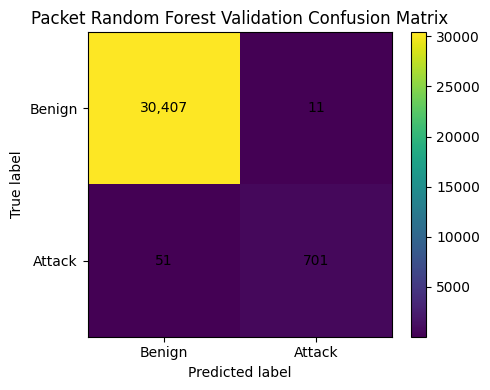

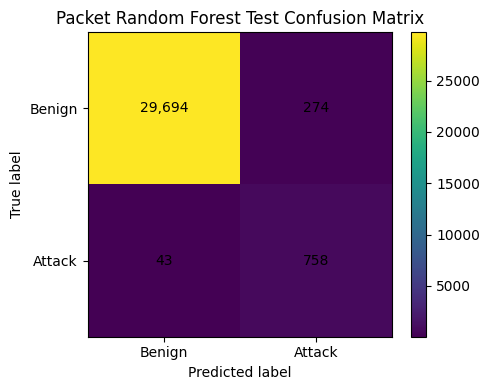

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_validation, validation_pred, "Packet Random Forest Validation Confusion Matrix")
plot_confusion_matrix(y_test, test_pred, "Packet Random Forest Test Confusion Matrix")


### Test classification report


In [8]:
report = classification_report(
    y_test,
    test_pred,
    target_names=["Benign", "Attack"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
display(report_df.round(4))


,precision,recall,f1-score,support
Benign,0.9986,0.9909,0.9947,29968.0000
Attack,0.7345,0.9463,0.8271,801.0000
accuracy,0.9897,0.9897,0.9897,0.9897
macro avg,0.8665,0.9686,0.9109,30769.0000
weighted avg,0.9917,0.9897,0.9903,30769.0000


### Results by traffic type


,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,29968,29694,274,99.09
DDoS-HTTP Flood,124,119,5,95.97
DoS-HTTP Flood,58,54,4,93.10
DNS Spoofing,532,512,20,96.24
Brute Force,58,54,4,93.10
XSS,29,19,10,65.52


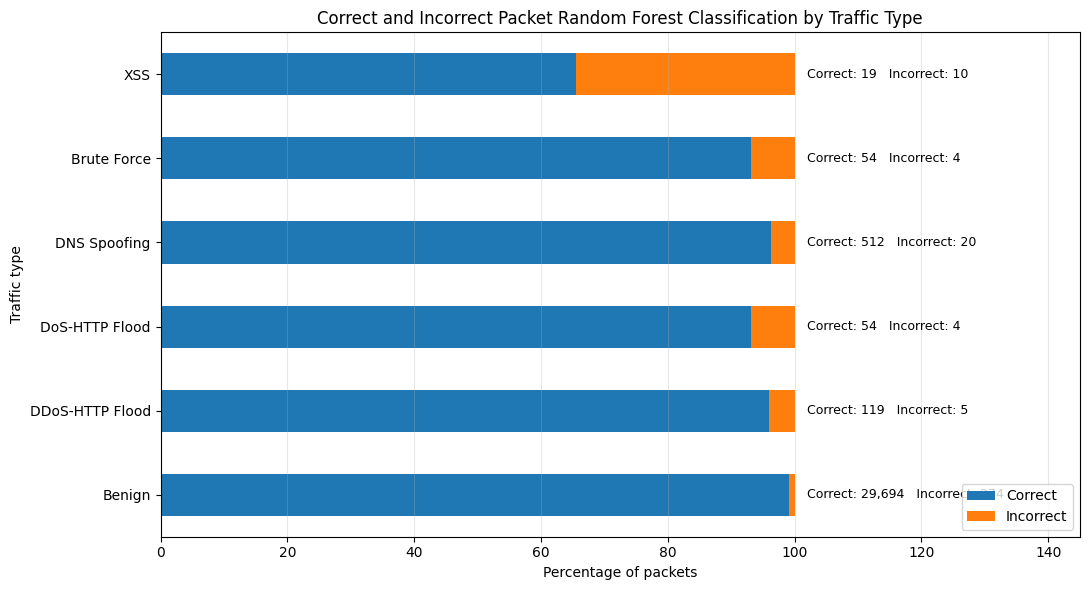

In [9]:
type_results = test_df[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of packets")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Packet Random Forest Classification by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### ROC and precision-recall curves


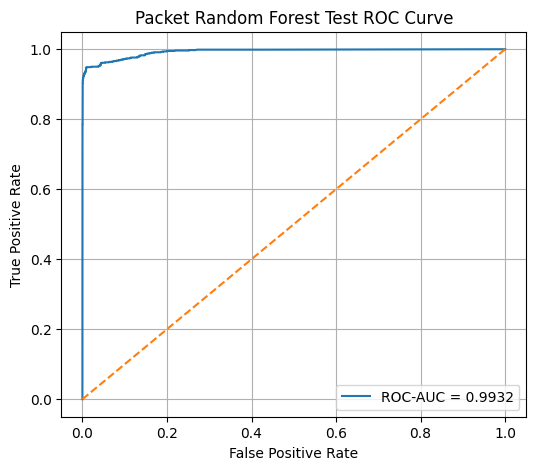

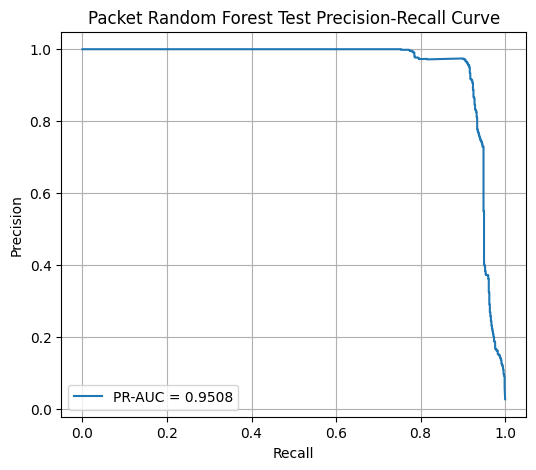

In [10]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curve(y_test, test_scores, "Packet Random Forest Test ROC Curve")
plot_precision_recall_curve(y_test, test_scores, "Packet Random Forest Test Precision-Recall Curve")


## Tuned model feature importance

Feature importance measures how much each processed packet feature reduces impurity across the trees.


,feature,importance
0,inter_arrival_time,0.402973
1,l3_ip_dst_count,0.071571
2,channel_30_var,0.060018
3,src_ip_mac_5_count,0.042504
4,channel_30_mean,0.035274
5,src_ip_mac_30_count,0.031233
6,src_ip_5_count,0.029954
7,src_ip_30_count,0.027561
8,min_et,0.026845
9,min_e,0.025753


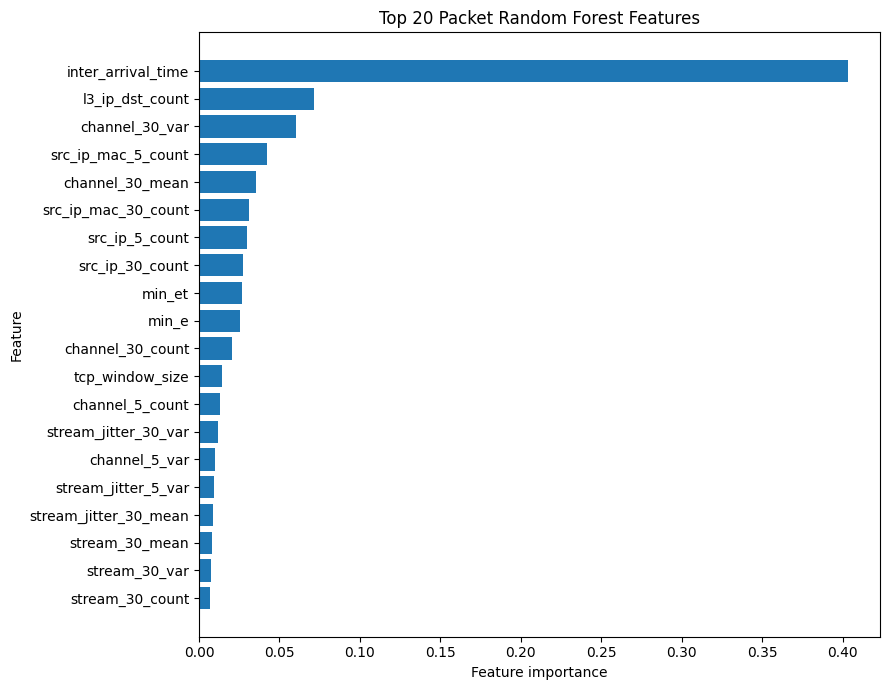

In [11]:
processed_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out(feature_cols)
feature_importance = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

plot_importance = importance_df.head(20).sort_values("importance")
plt.figure(figsize=(9, 7))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Packet Random Forest Features")
plt.tight_layout()
plt.show()


## Save the packet-level results


In [12]:
# RESULTS_DIR = PROJECT_ROOT / "reports" / "phase3"
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# metrics_output = metrics_df.copy()
# metrics_output.insert(0, "model", "Packet Random Forest Tuned")
# metrics_output["search_time_sec"] = search_time
# metrics_output["refit_time_sec"] = rf_search.refit_time_
# metrics_output.to_csv(RESULTS_DIR / "packet_random_forest_tuned_metrics.csv", index=False)

# importance_df.to_csv(RESULTS_DIR / "packet_random_forest_tuned_feature_importance.csv", index=False)
# cv_results_df.to_csv(RESULTS_DIR / "packet_random_forest_random_search_results.csv", index=False)

# best_parameters = {
#     "best_cv_pr_auc": rf_search.best_score_,
#     "search_time_sec": search_time,
#     "refit_time_sec": rf_search.refit_time_,
#     "n_iter": N_ITER,
#     "cv_folds": cv.get_n_splits(),
#     "classification_threshold": CLASSIFICATION_THRESHOLD,
#     "input_feature_count": len(feature_cols),
#     "input_features": feature_cols,
#     "preprocessing": [
#         "numeric conversion",
#         "structural variance and jitter missing values filled with zero",
#         "median imputation with missing indicators",
#         "constant feature removal"
#     ],
#     "best_params": rf_search.best_params_
# }

# with open(RESULTS_DIR / "packet_random_forest_best_parameters.json", "w") as f:
#     json.dump(best_parameters, f, indent=2)

# prediction_cols = [PACKET_ID_COL, PACKET_FLOW_KEY_COL, ATTACK_COL, BINARY_COL, TARGET_COL]
# test_predictions = test_df[prediction_cols].copy()
# test_predictions["attack_probability"] = test_scores
# test_predictions["prediction"] = test_pred
# test_predictions.to_csv(RESULTS_DIR / "packet_random_forest_tuned_test_predictions.csv", index=False)

# print("Saved packet Random Forest results to:", RESULTS_DIR)


## Final packet Random Forest summary


In [13]:
test_row = metrics_df.loc[metrics_df["dataset"] == "Test"].iloc[0]

print("Final packet Random Forest test results")
print("---------------------------------------")
print(f"Best mean CV PR-AUC: {rf_search.best_score_:.4f}")
print(f"Accuracy: {test_row['accuracy']:.4f}")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Search time: {search_time:.2f} seconds")
print(f"Best-model refit time: {rf_search.refit_time_:.2f} seconds")
print(f"Test prediction time: {test_prediction_time:.2f} seconds")

print()
print("Best hyperparameters")
for name, value in rf_search.best_params_.items():
    print(f"{name}: {value}")

print()
print("Correct classification rate by traffic type")
for attack_type in result_by_type.index:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")


Final packet Random Forest test results
---------------------------------------
Best mean CV PR-AUC: 0.9933
Accuracy: 0.9897
Precision: 0.7345
Recall: 0.9463
F1-score: 0.8271
ROC-AUC: 0.9932
PR-AUC: 0.9508
FPR: 0.0091
FNR: 0.0537
Search time: 3362.40 seconds
Best-model refit time: 506.28 seconds
Test prediction time: 0.20 seconds

Best hyperparameters
model__n_estimators: 500
model__min_samples_split: 5
model__min_samples_leaf: 1
model__max_features: 0.3
model__max_depth: 30
model__class_weight: balanced
model__bootstrap: False

Correct classification rate by traffic type
Benign: 99.09%
DDoS-HTTP Flood: 95.97%
DoS-HTTP Flood: 93.10%
DNS Spoofing: 96.24%
Brute Force: 93.10%
XSS: 65.52%
